In [1]:
import sys, os
sys.path.insert(0, '/local/data/public/skcb2/tddft/inq-stack/python')
import numpy as np
from IPython.display import Image, display
from inqview.visualisation import style
style.apply_theme()
SYS = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium'
print('theme applied; provenance root:', SYS)

theme applied; provenance root: /local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium


# sigma1_masspair study — the artifact returns in the clean geometry

**Design goal** (plan `docs/plans/sigma1-masspair-decay-runs.md`): reproduce
the clean run's monotonic energy decay with a σ_ρ=1, heavier-mass packet.
**Result: refuted** — both runs show the drain-then-rise artifact at full
strength, in the geometry that decays monotonically at σ=0.5/m=1/100 eV.
That failure is highly informative; this notebook extracts the three new
facts.

| run | m | v | E_kin | drain | t_min | rise after min |
|---|---|---|---|---|---|---|
| wp_m2_k4p5 | 2 | 2.25 | 138 eV | 60 eV | 32.6 | **+180 eV** |
| wp_m3_k4p5 | 3 | 1.50 | 92 eV | 44 eV | 50.2 | **+125 eV** |
| p3_wp_m1_rerun (clean ref) | 1 | 2.71 | 100 eV | 126 eV | 97.9 | +0.11 eV |


## §1 — ΔE_total overlays (both runs + the clean m=1 reference)

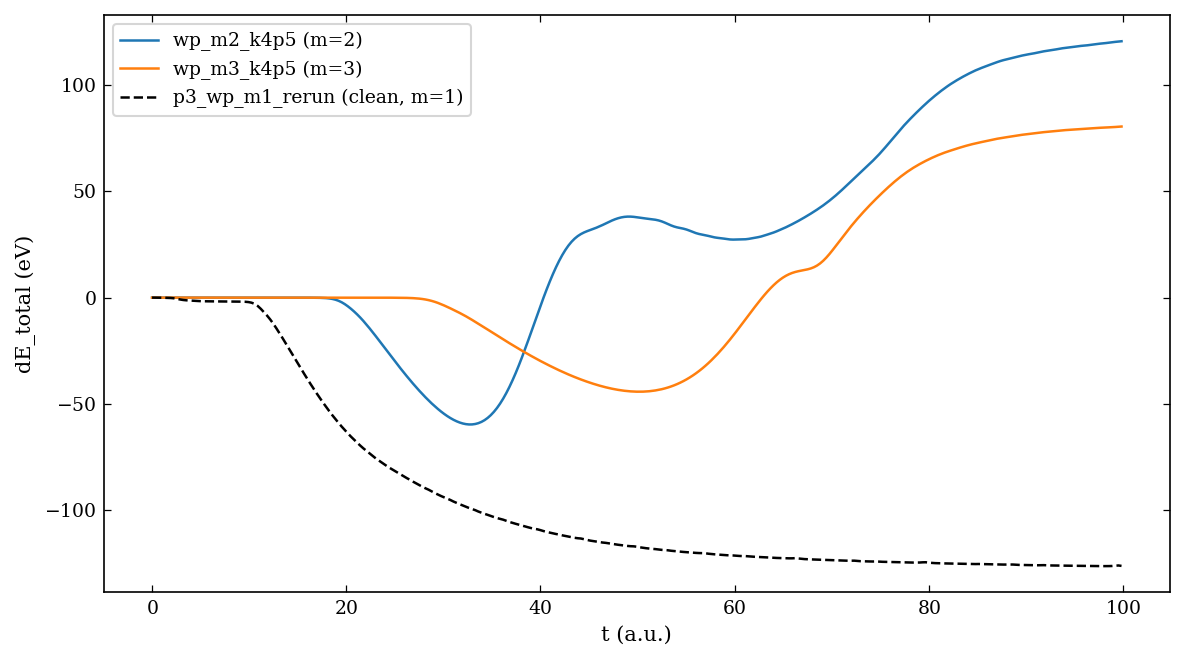

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
HA = 27.211386
WPRES = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/sigma1_masspair/wp/results'
P3RES = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/qsp_phase3/wp/results/p3_wp_m1_rerun'
os.makedirs("figs", exist_ok=True)
def load(run):
    d = {}
    d["obs"] = pd.read_csv(f"{WPRES}/{run}/raw/observables/observables.csv")
    d["ix"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/interactions.csv")
    d["rs"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/wp_real_space_stats.csv", skiprows=1)
    d["ms"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/wp_momentum_stats.csv", skiprows=1)
    d["ne"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/electron_number.csv")
    d["se"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/state_energies.csv")
    return d
runs = {"wp_m2_k4p5": 2, "wp_m3_k4p5": 3}
D = {r: load(r) for r in runs}
p3 = pd.read_csv(f"{P3RES}/raw/observables/observables.csv")
fig, ax = plt.subplots(figsize=(8, 4.5))
for r in runs:
    o = D[r]["obs"]
    ax.plot(o.time_au, (o.energy_total-o.energy_total.iloc[0])*HA, label=f"{r} (m={runs[r]})")
ax.plot(p3.time_au, (p3.energy_total-p3.energy_total.iloc[0])*HA, "k--", label="p3_wp_m1_rerun (clean, m=1)")
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("dE_total (eV)"); ax.legend()
fig.tight_layout(); fig.savefig("figs/study_overlay.png", dpi=150); plt.show()

## §2 — The clock: t_min tracks the projectile's CAP arrival

t_min ratio between the runs equals the velocity ratio, and in both runs
t_min ≈ 1.44 × the ballistic launch→far-CAP-face time — while the WP-state
norm crosses the same ~5 % at t_min. The clock is the completion of CAP
absorption of the projectile, not slow-spill arrival (which the earlier
campaigns assumed).

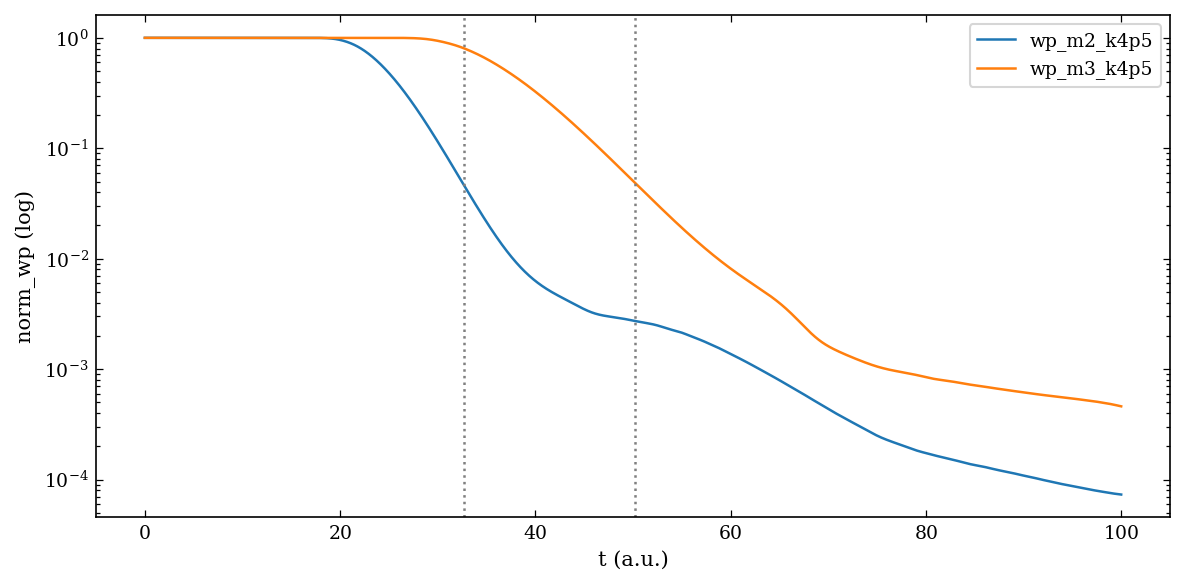

run              m     v  t_min  t_cap  ratio norm@t_min
wp_m2_k4p5       2  2.25   32.6   22.9   1.43     0.0470
wp_m3_k4p5       3  1.50   50.2   34.3   1.46     0.0483
t_min ratio 1.54 vs velocity ratio 1.50


In [3]:
rows = []
fig, ax = plt.subplots(figsize=(8, 4))
for r, m in runs.items():
    o, ix = D[r]["obs"], D[r]["ix"]
    t, E = o.time_au.values, o.energy_total.values
    im = int(E.argmin()); v = 4.5/m
    t_cap = (35-(-16.5))/v
    j = int(np.searchsorted(ix.time_au.values, t[im]))
    rows.append((r, m, v, t[im], t_cap, t[im]/t_cap, ix.norm_wp.iloc[j]))
    ax.semilogy(ix.time_au, ix.norm_wp, label=f"{r}")
    ax.axvline(t[im], ls=":", color="0.5")
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("norm_wp (log)"); ax.legend()
fig.tight_layout(); fig.savefig("figs/study_clock.png", dpi=150); plt.show()
print(f"{'run':14s} {'m':>3} {'v':>5} {'t_min':>6} {'t_cap':>6} {'ratio':>6} {'norm@t_min':>10}")
for r, m, v, tm, tc, ra, nw in rows:
    print(f"{r:14s} {m:3d} {v:5.2f} {tm:6.1f} {tc:6.1f} {ra:6.2f} {nw:10.4f}")
print(f"t_min ratio {rows[1][3]/rows[0][3]:.2f} vs velocity ratio {rows[0][2]/rows[1][2]:.2f}")

## §3 — Attribution: the rise is 100 % the kinetic ledger term

Change of each ledger component and each pairwise Coulomb channel over
t_min → τ. Kinetic carries the entire rise; Hartree/external nearly cancel
in their slab parts (e_ss vs e_sb); every projectile channel is ≤ 1.4 eV.

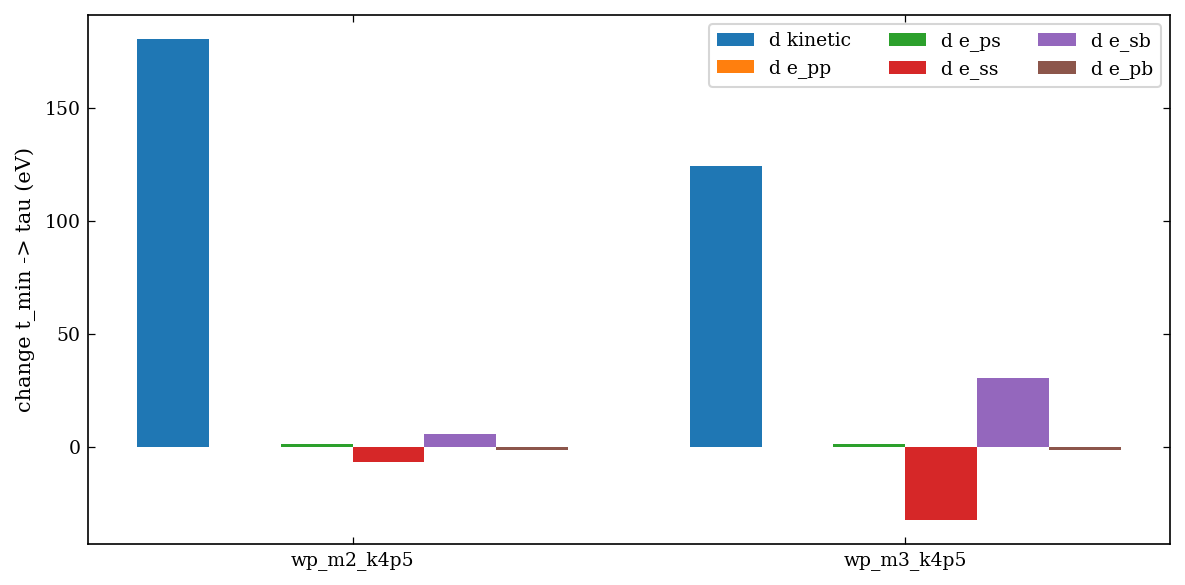

wp_m2_k4p5: d(kinetic)=+180.6 eV;  e_pp=-0.00  e_ps=+1.38  e_ss=-6.38  e_sb=+5.86  e_pb=-1.36
wp_m3_k4p5: d(kinetic)=+124.2 eV;  e_pp=-0.00  e_ps=+1.31  e_ss=-31.99  e_sb=+30.70  e_pb=-1.28


In [4]:
labels, kin, coul = [], [], {}
for r, m in runs.items():
    o, ix = D[r]["obs"], D[r]["ix"]
    t, E = o.time_au.values, o.energy_total.values
    im = int(E.argmin()); j = int(np.searchsorted(ix.time_au.values, t[im]))
    labels.append(r)
    kin.append((o.energy_kinetic.iloc[-1]-o.energy_kinetic.iloc[im])*HA)
    for c in ("e_pp","e_ps","e_ss","e_sb","e_pb"):
        coul.setdefault(c, []).append((ix[c].iloc[-1]-ix[c].iloc[j])*HA)
x = np.arange(len(labels)); w = 0.13
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x-2.5*w, kin, w, label="d kinetic")
for k, (c, vals) in enumerate(coul.items()):
    ax.bar(x+(k-1.5)*w, vals, w, label="d "+c)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("change t_min -> tau (eV)")
ax.legend(ncol=3); fig.tight_layout(); fig.savefig("figs/study_attribution.png", dpi=150); plt.show()
for i, r in enumerate(labels):
    print(f"{r}: d(kinetic)={kin[i]:+.1f} eV;  " +
          "  ".join(f"{c}={coul[c][i]:+.2f}" for c in coul))

## §4 — The mechanism at state level

The WP state's raw energy expectation ⟨φ|H|φ⟩ (occupation-weighted) decays to
zero as the CAP absorbs it — but INQ's kinetic ledger divides by the state
norm (`energy.hpp`: occ·⟨φ|T|φ⟩/⟨φ|φ⟩). The *ratio* for the surviving sliver
climbs (≈5.5 → ≈14 Ha for m=2): the CAP preferentially removes the packet's
core and leaves a high-kinetic residue whose normalised energy diverges as
norm → 1e-4. The m=1 clean runs end with a *slow* residue instead (rise
0.11 eV). Why the massive/faster-k0 packet leaves a fast residue (reflected
high-k components near Nyquist?) is the open question.

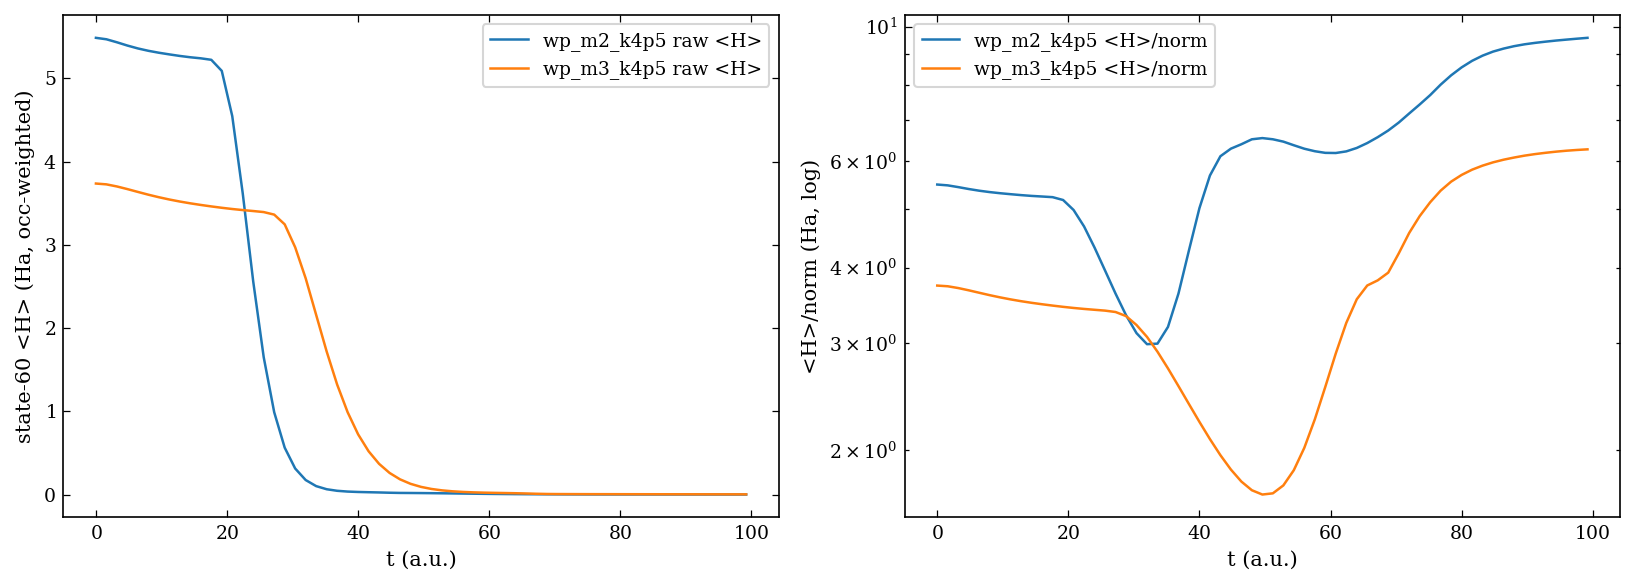

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for r, m in runs.items():
    se = D[r]["se"]; w = se[se.state_index==60]
    ax[0].plot(w.time_au, w.E_expect_ha, label=f"{r} raw <H>")
    ix = D[r]["ix"]
    nrm = np.interp(w.time_au.values, ix.time_au.values, ix.norm_wp.values)
    ax[1].semilogy(w.time_au, w.E_expect_ha/np.maximum(nrm, 1e-12), label=f"{r} <H>/norm")
ax[0].set_xlabel("t (a.u.)"); ax[0].set_ylabel("state-60 <H> (Ha, occ-weighted)"); ax[0].legend()
ax[1].set_xlabel("t (a.u.)"); ax[1].set_ylabel("<H>/norm (Ha, log)"); ax[1].legend()
fig.tight_layout(); fig.savefig("figs/study_state60.png", dpi=150); plt.show()

## §5 — Implications for the oscillation investigation

1. **H1 (large CAP standoff protects) is refuted as sufficient** — identical
   clean geometry, violent artifact.
2. **The mass/k0 correlation is restored**: every oscillating run to date has
   m_eff>1 (2.10 family; now 2 and 3) and/or k0 well above 2.7; every clean
   run is m=1, k0=2.711. The engine-level ledger audit (m=1 bit-identity)
   does not cover the m>1 dynamics.
3. **New clock law**: t_min = completion of CAP absorption of the projectile
   state (norm ≈ 5 %), scaling as 1/v — reinterprets the cap_fix
   "period-lengthening ladder" as absorption-completion shifts.
4. Sharpest next discriminators: (a) m=1 twin at k0=4.5/σ_ρ=1 in this exact
   geometry (separates mass from k0/σ); (b) recompute E_total excluding the
   WP state's norm-divided term (zero-GPU, from state_energies +
   observables) to confirm the ledger identity; (c) τ-extension of a clean
   run (the checkpoints allow it directly).

Review path: per-run notebooks → this study → handover
`docs/handovers/energy-oscillation-debugging.md`.